# Reporte de Transfer Curves — EGOFET

Visualización de todas las mediciones de transfer de un archivo HDF5,
con extracción automática de $V_{th}$ por el método $\sqrt{|I_{DS}|}$.

Para cambiar de archivo, modifica la variable `hdf5_name` en la celda de setup.


In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(marker='src'):
    cwd = Path(os.getcwd()).resolve()
    for parent in [cwd, *cwd.parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(f"No se encontro project root con '{marker}'")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from src.readers.keithley_dean import list_measurements, read_curve, read_all_curves
from src.plotting import plot_transfer
from src.analysis import extract_vth_for_transfers

# === Seleccionar archivo hdf5 (cambiar aqui) ===
hdf5_name = "2026-06-30_test3.hdf5"
hdf5_path = PROJECT_ROOT / 'data' / 'raw' / hdf5_name

print(f"Archivo: {hdf5_name}")
print(f"Ruta:    {hdf5_path}")


Archivo: 2026-06-30_test3.hdf5
Ruta:    /home/dibarra/Documents/egofets-project/data/raw/2026-06-30_test3.hdf5


In [2]:
measurement_list_dic = list_measurements(hdf5_path)
transfer_measurements = [m["name"] for m in measurement_list_dic if m["mode"] == "transfer"]
print(f"Transfer measurements ({len(transfer_measurements)}):")
for m in transfer_measurements:
    print(f"  - {m}")


Transfer measurements (9):
  - 010626_batch1_mta1_00
  - 010626_batch1_mta1_03
  - 010626_batch2_mta1_00
  - 010626_batch2_mta1_02
  - 010626_batch3_mta1_00
  - 010626_batch3_mta1_03
  - 010626_batch4_mta1_00
  - 010626_batch4_mta1_02
  - 010626_batch4_mta1_03


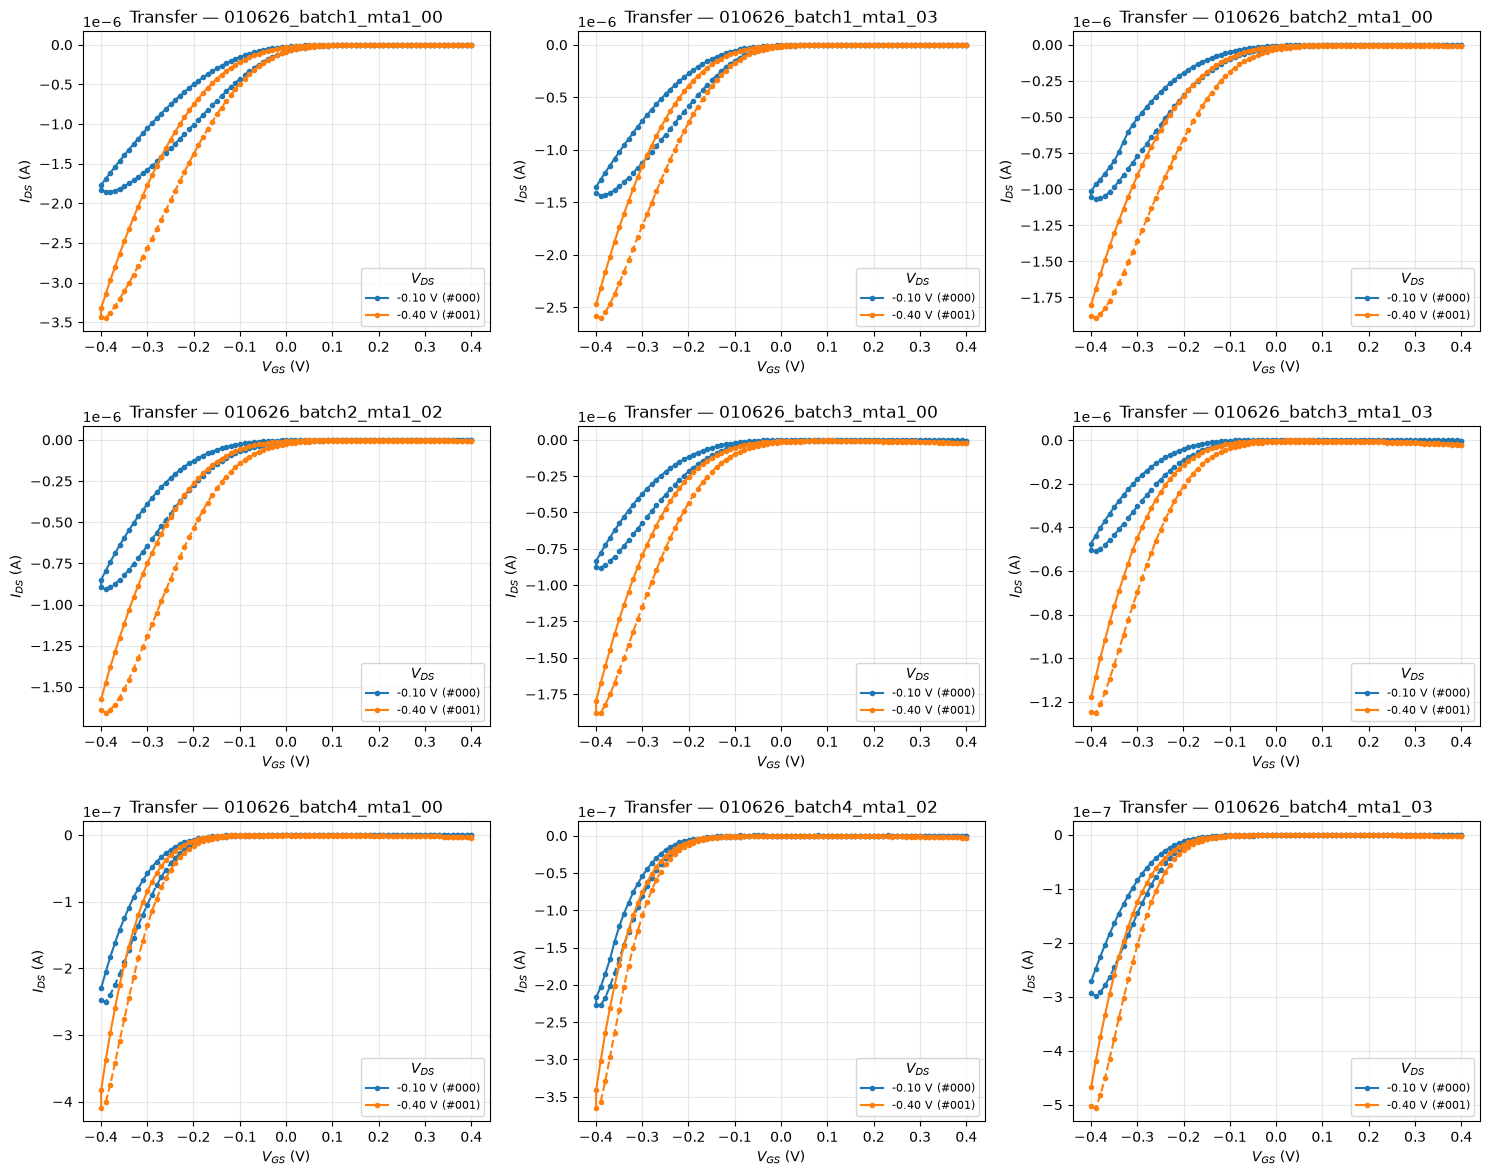

In [3]:
def plot_grid(hdf5_path, measurements, plot_func, ncols=3, figsize_per=(5, 4)):
    n = len(measurements)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows))
    axes_flat = np.array(axes).flatten() if n > 1 else np.array([axes])
    for ax, m_name in zip(axes_flat, measurements):
        plot_func(hdf5_path, m_name, ax=ax)
    for ax in axes_flat[len(measurements):]:
        ax.set_visible(False)
    plt.tight_layout()
    return fig

fig = plot_grid(hdf5_path, transfer_measurements, plot_transfer)
plt.show()


In [11]:
df_vth = extract_vth_for_transfers(
    hdf5_path, transfer_measurements,
    v_min_range=(-0.40, -0.38),
    v_max_range=(-0.06, -0.00),
)
display(df_vth)


,measurement,V_DS (V),V_th (V),v_min (V),v_max (V),R^2,n_points
0,010626_batch1_mta1_00,-0.400143,0.000303,-0.39,-0.06,0.997344,33
1,010626_batch1_mta1_03,-0.400221,-0.043608,-0.40,-0.06,0.992679,34
2,010626_batch2_mta1_00,-0.400207,-0.018048,-0.39,-0.06,0.995481,33
3,010626_batch2_mta1_02,-0.400066,-0.035362,-0.40,-0.06,0.992697,34
4,010626_batch3_mta1_00,-0.400090,-0.045906,-0.39,-0.06,0.987097,33
5,010626_batch3_mta1_03,-0.400136,-0.074421,-0.40,-0.06,0.975824,34
6,010626_batch4_mta1_00,-0.400176,-0.121952,-0.40,-0.06,0.916028,35
7,010626_batch4_mta1_02,-0.400167,-0.115551,-0.39,-0.06,0.917220,33
8,010626_batch4_mta1_03,-0.400181,-0.108086,-0.40,-0.06,0.938825,34


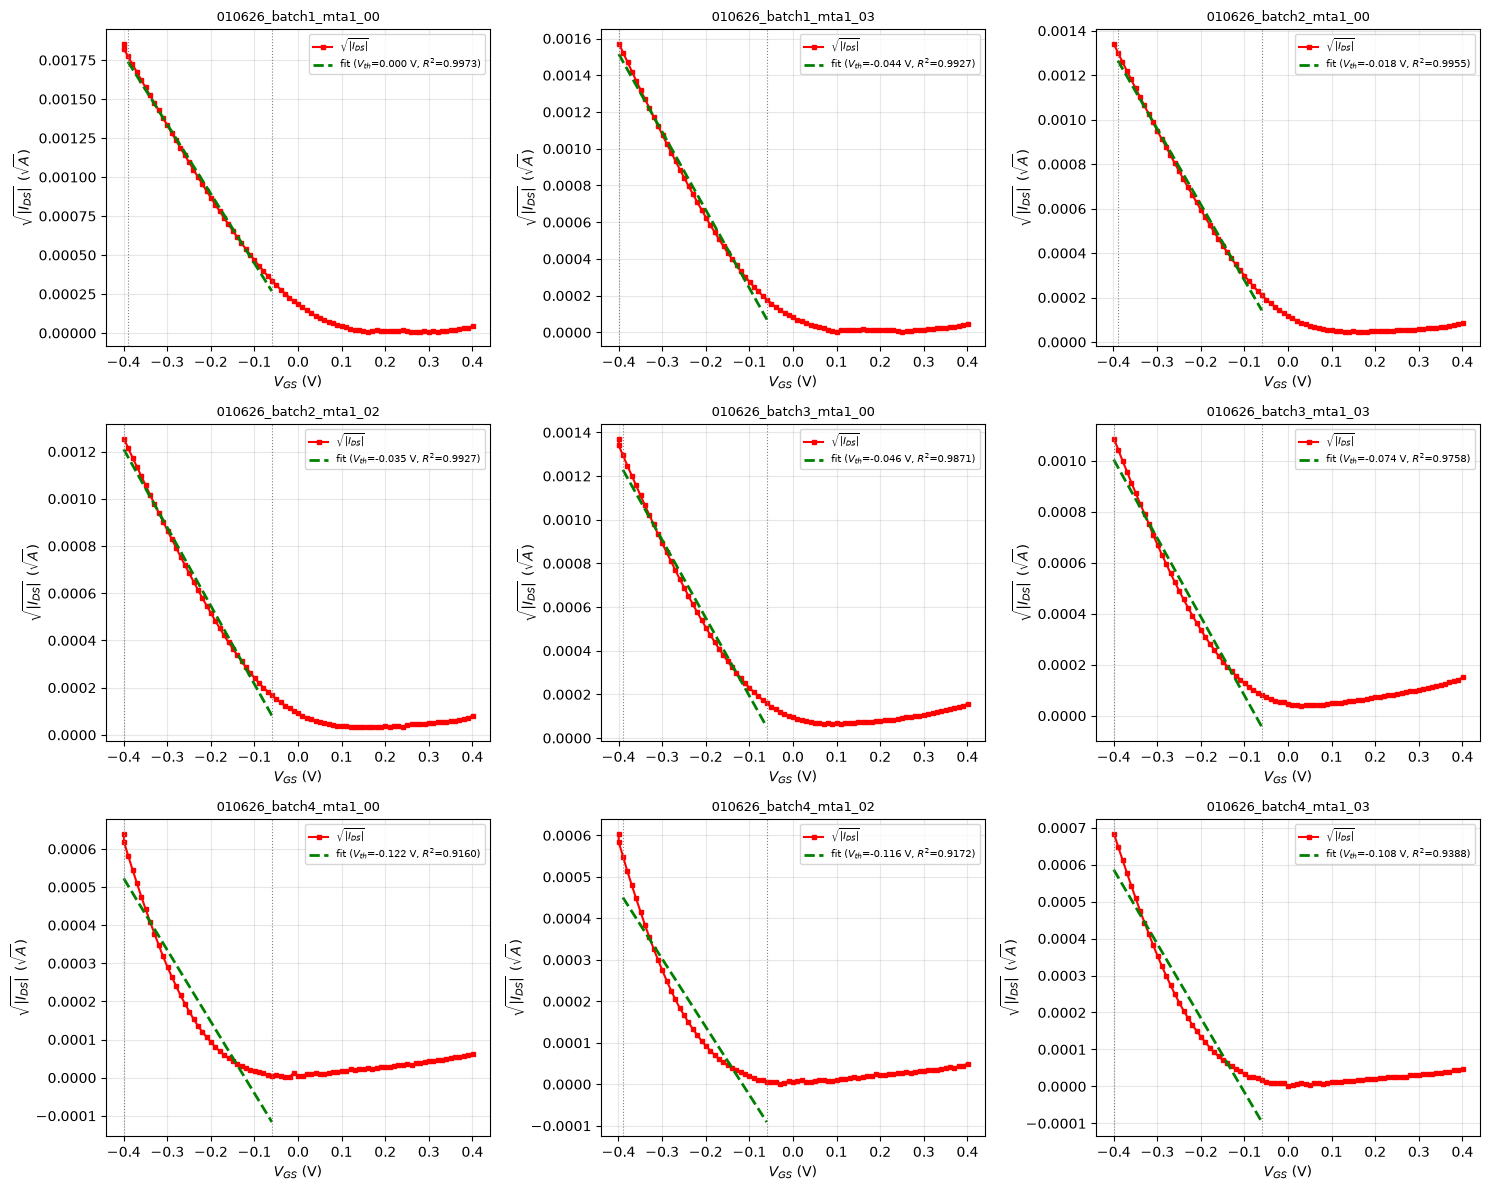

In [12]:
from scipy.stats import linregress

def plot_linearized_grid(hdf5_path, df_vth, ncols=3, figsize_per=(5, 4)):
    n = len(df_vth)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows))
    axes_flat = np.array(axes).flatten() if n > 1 else np.array([axes])
    for ax, row in zip(axes_flat, df_vth.itertuples()):
        m_name = row.measurement
        v_min_w, v_max_w = row._4, row._5
        try:
            curves = read_all_curves(hdf5_path, m_name)
            i_max = max(range(len(curves)), key=lambda i: abs(curves[i]['v_ds'][0]))
            curve = curves[i_max]
            v_gs_fwd, i_ds_fwd = read_curve(hdf5_path, m_name, curve['curve_name'], fwd_only=True)
            sqrt_ids = np.sqrt(np.abs(i_ds_fwd))
            mask = (v_gs_fwd >= v_min_w) & (v_gs_fwd <= v_max_w)
            slope, intercept, r_value, _, _ = linregress(v_gs_fwd[mask], sqrt_ids[mask])
            v_th = -intercept / slope
            ax.plot(v_gs_fwd, sqrt_ids, 'rs-', ms=3, label=r'$\sqrt{|I_{DS}|}$')
            x_fit = np.array([v_min_w, v_max_w])
            y_fit = slope * x_fit + intercept
            ax.plot(x_fit, y_fit, 'g--', lw=2, label=f'fit ($V_{{th}}$={v_th:.3f} V, $R^2$={r_value**2:.4f})')
            ax.axvline(v_min_w, color='gray', ls=':', lw=0.8)
            ax.axvline(v_max_w, color='gray', ls=':', lw=0.8)
            ax.set_xlabel(r'$V_{GS}$ (V)')
            ax.set_ylabel(r'$\sqrt{|I_{DS}|}$ ($\sqrt{A}$)')
            ax.set_title(m_name, fontsize=9)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {e}', transform=ax.transAxes, ha='center')
    for ax in axes_flat[len(df_vth):]:
        ax.set_visible(False)
    plt.tight_layout()
    return fig

if len(df_vth) > 0:
    fig = plot_linearized_grid(hdf5_path, df_vth)
    plt.show()
else:
    print("No hay datos de V_th para graficar")


In [6]:
if len(df_vth) > 0:
    os.makedirs(PROJECT_ROOT / 'output', exist_ok=True)
    base = Path(hdf5_name).stem
    csv_path = PROJECT_ROOT / 'output' / f'vth_{base}.csv'
    df_vth.to_csv(csv_path, index=False)
    print(f"Guardado en {csv_path}")


Guardado en /home/dibarra/Documents/egofets-project/output/vth_2026-06-30_test3.csv
